## Importacion de librerias

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Cargue de datos

In [2]:
DATA_DIR = Path.cwd().resolve().parent / "modelos"

data = joblib.load(DATA_DIR / "randomForest_best_model.joblib")

In [3]:
preprocessor = data.named_steps["preprocessor"]
classifier = data.named_steps["classifier"]

## Preprocesador

In [4]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['age', 'heart_rate', 'systolic_bp',
                                  'diastolic_bp', 'blood_sugar', 'ckmb',
                                  'troponin']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender'])])

## Clasificador 

In [5]:
classifier

RandomForestClassifier(n_estimators=50, random_state=42)

## Valoracion numerica de las variables según su importancia

In [6]:
features = preprocessor.get_feature_names_out()
importances = classifier.feature_importances_

df_Features = pd.DataFrame({"Variables": features, "Importancia": importances})
df_Features_sorted = df_Features.sort_values(by="Importancia", ascending=False)
print(df_Features_sorted)

           Variables  Importancia
6      num__troponin     0.610525
5          num__ckmb     0.272150
0           num__age     0.046210
2   num__systolic_bp     0.020184
4   num__blood_sugar     0.015604
3  num__diastolic_bp     0.011428
1    num__heart_rate     0.010951
8      cat__gender_1     0.006535
7      cat__gender_0     0.006414


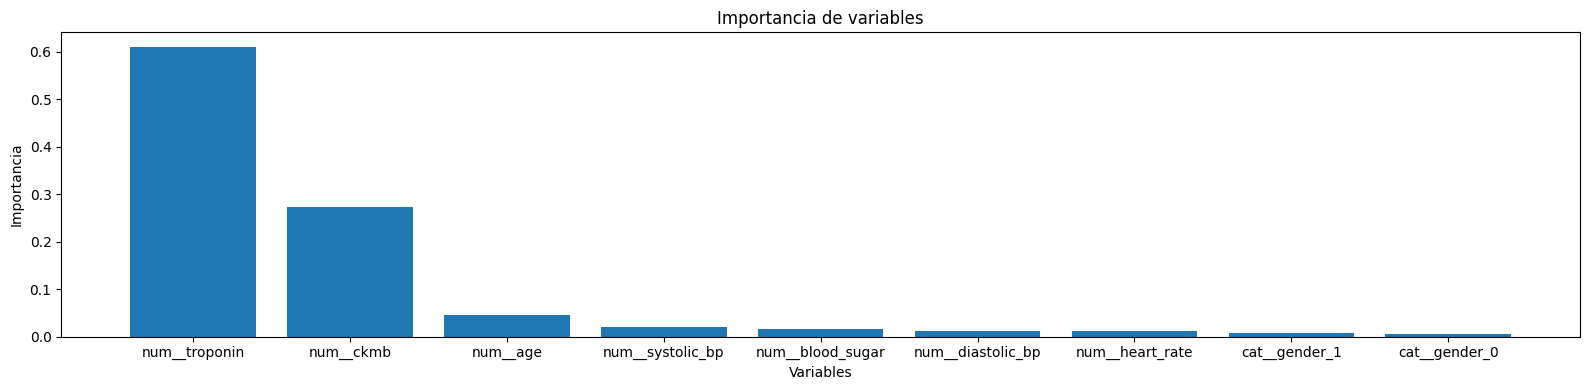

In [9]:
plt.figure(figsize=(16,4))
plt.bar(df_Features_sorted['Variables'],df_Features_sorted['Importancia'])

plt.title('Importancia de variables')
plt.xlabel('Variables')
plt.ylabel('Importancia')

plt.tight_layout()
plt.show()

## Conclusiones

Se realizaron dos versiones de prueba:
- 1. Se emplearon las variables `troponin` y la variable `ckmb`, estas como se observa en el grafico anterior son las variables con mayor importancia, lo que hace que el modelo sea casí que perfecto y por ende obtener un `accuracy` de `99%` donde el modelo parte de que conoce el resultado final
- 2. se corre una prueba sin las variables antes mencionadas y se identificó que el modelo obtiene un `accuracy` del `62%` dando a entender que sin estas variables el modelo intenta predecir.